## Section 1: Install Dependencies
This section installs necessary packages using pip, including the Gym library for reinforcement learning environments.

In [1]:
!pip install swig
!pip install gymnasium
!pip install box2d
!pip3 install box2d box2d-kengz

  Using cached Box2D-2.3.2.tar.gz (427 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'error'


  ERROR: Error [WinError 225] Operation did not complete successfully because the file contains a virus or potentially unwanted software while executing command python setup.py egg_info
ERROR: Could not install packages due to an OSError: [WinError 225] Operation did not complete successfully because the file contains a virus or potentially unwanted software



  Using cached Box2D-2.3.2.tar.gz (427 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'error'


  ERROR: Error [WinError 225] Operation did not complete successfully because the file contains a virus or potentially unwanted software while executing command python setup.py egg_info
ERROR: Could not install packages due to an OSError: [WinError 225] Operation did not complete successfully because the file contains a virus or potentially unwanted software



## Section 2: Import Libraries
Imports necessary libraries such as Gym for the environment, Matplotlib for plotting, NumPy for numerical operations, and PyTorch for neural network-related functionalities.

In [2]:
import gym
import matplotlib.pyplot as plt
import numpy as np

import torch
from torch import nn
from torch import optim
from torch.distributions.categorical import Categorical




## Section 3: Define Constants
Defines a constant DEVICE as 'cpu' and a variable x with a value of 1.

In [3]:
DEVICE = 'cpu'
x=1

## Section 4: Define ActorCriticNetwork
Defines a neural network class (ActorCriticNetwork) for the actor-critic model. It has shared layers, policy layers, and value layers. The network takes observations as input and outputs policy logits and a value estimate.

In [5]:
#policy and value
class ActorCriticNetwork(nn.Module):
    def __init__(self, obs_space_size=153, action_space_size=30):
        super(ActorCriticNetwork, self).__init__()

        self.shared_layers = nn.Sequential(
            nn.Linear(153, 128),
            nn.ReLU(),
            nn.Linear(128, 128), 
            nn.LeakyReLU()
        )

        # Policy head
        self.policy_layers = nn.Sequential(
            nn.Linear(128, 64),  # Adjust hidden layer size
            nn.ReLU(),
            nn.Linear(64, action_space_size),
            nn.Softmax(dim=-1)  # Softmax layer for discrete action space
        )

        # Value head
        self.value_layers = nn.Linear(128, 1)  # Output a single value


In [9]:
# Use the following line to instantiate the model with adjusted architecture
actor_critic = ActorCriticNetwork(obs_space_size=153, action_space_size=30)

In [12]:
def forward(self, obs):
    shared_output = self.shared_layers(obs)
    policy_logits = self.policy_layers(shared_output)
    value = self.value_layers(shared_output)
    return policy_logits, value

In [13]:
def policy(self, obs):
        z = self.shared_layers(obs)
        policy_logits = self.policy_layers(z)
        return policy_logits
def value(self, obs):
        z = self.shared_layers(obs)
        value = self.value_layers(z)
        return value


## Section 5: Define PPOTrainer
Defines a PPOTrainer class responsible for training the actor-critic model using the Proximal Policy Optimization algorithm. It includes methods for training the policy and value networks, calculating advantages, and performing rollouts.

In [14]:
import torch
from torch.distributions import Categorical
import numpy as np
import torch.optim as optim

In [15]:
class PPOTrainer:
    def __init__(self, actor_critic, ppo_clip_val=0.2, target_kl_div=0.01, 
                 max_policy_train_iters=80, value_train_iters=80, 
                 policy_lr=3e-4, value_lr=3e-4):
        self.ac = actor_critic
        self.ppo_clip_val = ppo_clip_val
        self.target_kl_div = target_kl_div
        self.max_policy_train_iters = max_policy_train_iters
        self.value_train_iters = value_train_iters

        policy_params = list(self.ac.shared_layers.parameters()) + list(self.ac.policy_layers.parameters())
        self.policy_optim = optim.Adam(policy_params, lr=policy_lr)

        value_params = list(self.ac.shared_layers.parameters()) + list(self.ac.value_layers.parameters())
        self.value_optim = optim.Adam(value_params, lr=value_lr)

In [16]:
# Use the following line to adjust hyperparameters based on the provided values
ppo_trainer = PPOTrainer(actor_critic, ppo_clip_val=0.1, target_kl_div=0.05, policy_lr=1e-3, value_lr=1e-3)

In [60]:
def train_policy(self, obs, acts, old_log_probs, gaes):
    for _ in range(self.max_policy_train_iters):
        self.policy_optim.zero_grad()
        # Calculate new log probabilities of actions
        new_logits = self.ac.policy(obs)
        new_probs = Categorical(logits=new_logits)
        new_log_probs = new_probs.log_prob(acts)
        # Calculate policy ratio
        policy_ratio = torch.exp(new_log_probs - old_log_probs)
        clipped_ratio = policy_ratio.clamp(1 - self.ppo_clip_val, 1 + self.ppo_clip_val)
        if gaes.ndim > 1 and gaes.shape[0] == clipped_ratio.shape[0]:
            gaes = gaes.mean(dim=1)  # or gaes.sum(dim=1), depending on your requirement
            # Print shapes of clipped_ratio and gaes before the error line
            print("clipped_ratio shape:", clipped_ratio.shape)
            print("gaes shape:", gaes.shape)
            clipped_loss = clipped_ratio * gaes
            full_loss = policy_ratio * gaes
            policy_loss = -torch.min(full_loss, clipped_loss).mean()
            policy_loss.backward()
            self.policy_optim.step()
            kl_div = (old_log_probs - new_log_probs).mean()
            if kl_div >= self.target_kl_div:
                break

In [61]:
def train_value(self, obs, returns):
    for _ in range(self.value_train_iters):
        self.value_optim.zero_grad()
        values = self.ac.value(obs)
        value_loss = (returns - values) ** 2
        value_loss = value_loss.mean()
        value_loss.backward()
        self.value_optim.step()

In [62]:
@staticmethod
def discount_rewards(rewards, gamma=0.98):
    discounted_rewards = np.zeros_like(rewards, dtype=np.float32)
    running_add = 0
    for t in reversed(range(len(rewards))):
        running_add = running_add * gamma + rewards[t]
        discounted_rewards[t] = running_add
        return discounted_rewards

In [63]:
@staticmethod
def calculate_gaes(rewards, values, gamma=0.98, lambda_=0.95):
    advantages = np.zeros_like(rewards, dtype=np.float32)
    gae = 0
    next_values = np.append(values[1:], 0)  # Ensure next_values is shifted correctly
    for t in reversed(range(len(rewards))):
        delta = rewards[t] + gamma * next_values[t] - values[t]
        gae = delta + gamma * lambda_ * gae
        advantages[t] = gae
        return advantages

In [64]:
@staticmethod
def rollout(model, env, max_steps=1000):
    obs = env.reset()
    ep_reward = 0
    train_data = {'obs': [], 'acts': [], 'rewards': [], 'values': [], 'log_probs': []}
    for step in range(max_steps):
        obs_tensor = torch.tensor(obs, dtype=torch.float32)
        logits, val = model(obs_tensor)
        act_distribution = Categorical(logits=logits)
        act = act_distribution.sample()
        act_log_prob = act_distribution.log_prob(act)
        next_obs, reward, done, _ = env.step(act.item())
        ep_reward += reward
        train_data['obs'].append(obs)
        train_data['acts'].append(act.item())
        train_data['rewards'].append(reward)
        train_data['values'].append(val.item())
        train_data['log_probs'].append(act_log_prob.item())
        obs = next_obs
        if done:
            break
            for key in train_data.keys():
                train_data[key] = np.array(train_data[key])
                train_data['values'] = PPOTrainer.calculate_gaes(train_data['rewards'], train_data['values'])
                train_data['rewards'] = PPOTrainer.discount_rewards(train_data['rewards'])
                return train_data, ep_reward

## Section 6: Define SatelliteServiceEnv
Defines a custom Gym environment (SatelliteServiceEnv) for the satellite service allocation problem. It includes methods for initializing the environment, taking actions, calculating rewards, and resetting the environment.

In [65]:
import gym
import numpy as np
import random
import os
import pandas as pd
import pickle
import json
from gym import spaces


In [66]:
class SatelliteServiceEnv(gym.Env):
    def __init__(self, path_to='dataset_30/', n_services=50, n_satellites=10, api_cost=0.5, reward_scale=10):
        super(SatelliteServiceEnv, self).__init__()

        self.n_satellites = n_satellites
        self.n_services = n_services
        self.API_COST = api_cost
        self.REWARD_SCALE = reward_scale
        self.path_to = path_to
        self.load_and_merge_data(self.path_to)

        features_per_satellite = 5  # Adjust as needed
        features_per_service = 3  # Adjust as needed

        self.obs_space_size = features_per_satellite * self.n_satellites + features_per_service
        self.observation_space = spaces.Box(low=0, high=200, shape=(self.obs_space_size,), dtype=np.float32)
        self.action_space = spaces.Discrete(self.n_satellites)

        self.state = None
        self.current_service = 0
        self.prev_api_cost = None
        self.allocated_services = set()

        self.satellite_data = self.generate_satellite_data()
        self.service_data = self.generate_service_data()
        self.api_costs = self.generate_api_costs()

    def load_and_merge_data(self, path_to):
        if not isinstance(path_to, (str, bytes, os.PathLike)):
            raise ValueError(f"Invalid path: {path_to}")
        if not os.path.isdir(path_to):
            raise ValueError(f"Path is not a directory: {path_to}")

        # Initialize attributes
        self.api_data = None
        self.satellite_api_cost = None
        self.satellite_api = None
        self.service_api = None
        self.groundtruth_data = []

        for file in os.listdir(path_to):
            file_path = os.path.join(path_to, file)
            if os.path.isfile(file_path):
                if file.endswith(".csv"):
                    data = pd.read_csv(file_path, header=None)
                    if file == 'api_info.csv':
                        self.api_data = data
                    elif file == 'satellite_api_cost.csv':
                        self.satellite_api_cost = data
                    elif file == 'satellite_api.csv':
                        self.satellite_api = data
                    elif file == 'service_api.csv':
                        self.service_api = data
                elif file.startswith("groundtruth") and file.endswith(".txt"):
                    with open(file_path, 'r') as txt_file:
                        lines = txt_file.readlines()
                        for i in range(0, len(lines), 4):
                            api_list = json.loads(lines[i + 1].strip())
                            api_dict = json.loads(lines[i + 2].strip())
                            self.groundtruth_data.append({'api_list': api_list, 'api_dict': api_dict})

        pickle_path = os.path.join(path_to, "satellite_info.pickle")
        if os.path.exists(pickle_path):
            with open(pickle_path, 'rb') as file:
                self.satellite_info = pickle.load(file)

    def generate_satellite_data(self):
        return np.random.uniform(low=[75, 40, 2, 50, 20], high=[200, 200, 6, 100, 90], size=(self.n_satellites, 5)).flatten()

    def generate_service_data(self):
        return np.random.uniform(low=[1, 1, 1, 1], high=[75, 40, 5, 20], size=(self.n_services, 4)).flatten()

    def generate_api_costs(self):
        return np.random.uniform(1, 10, self.n_satellites)

    def get_current_state(self):
        satellite_index = self.current_service % self.n_satellites * 5
        service_index = self.current_service * 4
        satellite_data = self.satellite_data[satellite_index:satellite_index+5]
        service_data = self.service_data[service_index:service_index+4]

        reduced_api_costs = self.api_costs[:10]  # Example: taking the first 10 costs
        return np.concatenate((satellite_data, service_data, reduced_api_costs))

    def step(self, action):
        # Check if the action is valid
        if not self.action_space.contains(action):
            raise ValueError(f"Invalid action: {action} of type {type(action)}")

        try:
            # Update satellite resources based on the action
            self.update_satellite_resources(action)

            # Calculate the reward for the current action
            reward = self.calculate_reward(action)

            # Increment to the next service
            self.current_service += 1

            # Check if the episode has ended
            done = self.current_service == self.n_services

            # Get the current state of the environment
            self.state = self.get_current_state()

            # You can add additional info in the info dictionary if needed
            cost = self.api_costs[action]
            info = {'cost': cost}

            return self.state, reward, done, info
        except Exception as e:
            # Handle any unexpected errors
            print(f"An error occurred: {e}")
            # You might want to handle this differently depending on your needs
            raise e



    def is_episode_over(self):
        if self.current_service >= self.n_services:
            return True
        if len(self.allocated_services) >= self.n_services:
            return True
        if not self.any_feasible_allocations_remaining():
            return True
        return False

    def any_feasible_allocations_remaining(self):
        for self.current_service in range(self.current_service, self.n_services):
            if self.current_service in self.allocated_services:
                continue

            service_index = self.current_service * 4
            service = self.service_data[service_index:service_index+4]

            for satellite_id in range(self.n_satellites):
                satellite_index = satellite_id * 5
                satellite = self.satellite_data[satellite_index:satellite_index+5]

                if self.is_allocation_feasible(satellite, service):
                    return True
        return False

    def is_allocation_feasible(self, satellite, service):
        return (service[0] <= satellite[0]) and (service[1] <= satellite[1]) and (service[2] >= satellite[2]) and (service[3] <= satellite[3] * 0.2)
        

    def calculate_reward(self, action):
        # Validate action
        if not self.action_space.contains(action):
            raise ValueError(f"Invalid action: {action}")

        # Extracting satellite and service data based on the action and current service
        satellite_index = action * 5  # Adjust the number 5 if the satellite data structure changes
        service_index = self.current_service * 4  # Adjust the number 4 if the service data structure changes
        satellite = self.satellite_data[satellite_index:satellite_index + 5]
        service = self.service_data[service_index:service_index + 4]

        # Initialize reward
        reward = 0

        # Compliance rewards and penalties
        compliance_reward = 1
        penalty_for_violation = -1

        # Check for service requirements against satellite capabilities
        reward += compliance_reward if service[0] <= satellite[0] else penalty_for_violation  # CPU
        reward += compliance_reward if service[1] <= satellite[1] else penalty_for_violation  # Memory
        reward += compliance_reward if service[2] >= satellite[2] else penalty_for_violation  # Delay
        reward += compliance_reward if service[3] <= satellite[3] * 0.2 else penalty_for_violation  # Power

        # Check for temperature condition
        temperature_threshold = 80  # degrees
        reward += compliance_reward if satellite[4] < temperature_threshold else penalty_for_violation  # Temperature

        # Cost-based reward, normalized between 0 and 1
        min_cost = min(self.satellite_api_cost)
        max_cost = max(self.satellite_api_cost)
        normalized_cost = (max_cost - self.satellite_api_cost[action]) / (max_cost - min_cost)
        reward += normalized_cost * compliance_reward
        # Additional reward terms based on priorities
        uptime_reward = 2 * compliance_reward if service_uptime > 99 else penalty
        reward += uptime_reward
        return reward

In [67]:
# Adjust gamma in reward discounting closer to 1.
#discounted_rewards = PPOTrainer.discount_rewards(rewards, gamma=0.99)
  

In [68]:
def update_satellite_resources(self, action):
        satellite_index = action * 5
        service_index = self.current_service * 4
        service = self.service_data[service_index:service_index+4]

        self.satellite_data[satellite_index + 3] -= service[3]
        self.satellite_data[satellite_index] -= service[0]
        self.satellite_data[satellite_index + 1] -= service[1]
        self.api_costs[action] += 1


In [69]:
def reset(self):
        self.current_service = 0
        self.allocated_services = set()
        self.satellite_data = self.generate_satellite_data()
        self.api_costs = self.generate_api_costs()
        self.state = self.get_current_state()
        return self.state


In [76]:
def reset(self):
        self.current_service = 0
        self.allocated_services = set()
        self.satellite_data = self.generate_satellite_data()
        self.api_costs = self.generate_api_costs()
        self.state = self.get_current_state()
        return initial.state

In [80]:
def render(self, mode='console'):
        if mode == 'console':
            print(f"Current state: {self.state}")


## Section 7: Create an instance of SatelliteServiceEnv
Creates an instance of the custom environment and resets it to get the initial state.

In [82]:
env = SatelliteServiceEnv(path_to=r'C:\Users\HP\Desktop\DECWORK\dataset_30')
print(env)

<SatelliteServiceEnv instance>


In [83]:
print(env.observation_space)

Box(0.0, 200.0, (53,), float32)


In [84]:
print(env.observation_space.shape)

(53,)


In [105]:
print(env.action_space)

Discrete(10)


In [111]:
#  try:
#     env = SatelliteServiceEnv(path_to=r'C:\Users\HP\Desktop\DECWORK\dataset_30')
#     state = env.reset()
#     print(f"Size of state: {state.shape[0]}")
    
#     # Print the dimension of the observation space
#     print("Observation Space:", env.observation_space)
#     print("Observation Space Shape:", env.observation_space.shape)

#     # Print the dimension of the action space
#     print("Action Space:", env.action_space)
#     print("Number of Actions:", env.action_space.n if isinstance(env.action_space, gym.spaces.Discrete) else env.action_space.shape)
   
# except Exception as e:
#     print(f"Error creating environment: {e}") 

## Section 8:Initialize the ActorCriticNetwork and PPOTrainer

In [112]:
obs_space_size = env.observation_space.shape[0]
action_space_size = env.action_space.n
model = ActorCriticNetwork(obs_space_size, action_space_size)
ppo_trainer = PPOTrainer(model)

## Section 9: Perform a step in the environment
`Takes a random action in the environment`, `performs a step`, and `prints the cost` `associated with the selected satellite`.#
`Perform a step in the environment`
`Replace with your chosen action`
`Access the cost from the info dictionary`
`You can print the cost to see its value`

In [121]:
action = env.action_space.sample()

In [122]:
#state, reward, done, info = env.step(action)

In [124]:
# cost = info['cost']
# print(f"Cost of the selected satellite: {cost}")

## Section 10: Render the Environment
Renders the environment for 200 steps, displaying the state at each step.

In [127]:
# env.reset()
# for _ in range(200):
#     env.render()
#     observation, _, done, _ = env.step(env.action_space.sample())
#     if done:
#         break
# env.close()

## Section 11: Train the Agent with PPO
Trains the agent using the PPO algorithm by performing rollouts in the environment, updating the policy and value networks, and printing the average reward and cost.

In [128]:
import numpy as np
import torch
from torch.distributions import Categorical

# Training parameters
n_episodes = 1000  # Total number of training episodes
max_steps_per_episode = 250  # Max steps per episode
print_freq = 10  # Frequency of printing the average reward

# Trackers for rewards and costs
all_episode_rewards = []
all_episode_costs = []


In [135]:
for episode in range(n_episodes):
    obs = env.reset()
    episode_reward = 0
    episode_cost = 0
    episode_train_data = {'obs': [], 'acts': [], 'rewards': [], 'values': [], 'log_probs': []}
    if (episode + 1) % print_freq == 0:
        avg_reward = np.mean(all_episode_rewards[-print_freq:])
        avg_cost = np.mean(all_episode_costs[-print_freq:])
        print(f"Episode {episode + 1}/{n_episodes}, Average Reward: {avg_reward}, Average Cost: {avg_cost}")
    # Plot costs over episodes
    if (episode + 1) % print_freq == 0:
        avg_reward = np.mean(all_episode_rewards[-print_freq:])
        avg_cost = np.mean(all_episode_costs[-print_freq:])
        print(f"Episode {episode + 1}/{n_episodes}, Average Reward: {avg_reward}, Average Cost: {avg_cost}")

Episode 10/1000, Average Reward: nan, Average Cost: nan
Episode 10/1000, Average Reward: nan, Average Cost: nan
Episode 20/1000, Average Reward: nan, Average Cost: nan
Episode 20/1000, Average Reward: nan, Average Cost: nan
Episode 30/1000, Average Reward: nan, Average Cost: nan
Episode 30/1000, Average Reward: nan, Average Cost: nan
Episode 40/1000, Average Reward: nan, Average Cost: nan
Episode 40/1000, Average Reward: nan, Average Cost: nan
Episode 50/1000, Average Reward: nan, Average Cost: nan
Episode 50/1000, Average Reward: nan, Average Cost: nan
Episode 60/1000, Average Reward: nan, Average Cost: nan
Episode 60/1000, Average Reward: nan, Average Cost: nan
Episode 70/1000, Average Reward: nan, Average Cost: nan
Episode 70/1000, Average Reward: nan, Average Cost: nan
Episode 80/1000, Average Reward: nan, Average Cost: nan
Episode 80/1000, Average Reward: nan, Average Cost: nan
Episode 90/1000, Average Reward: nan, Average Cost: nan
Episode 90/1000, Average Reward: nan, Average Co

In [146]:
print(f"Obs array: {obs}")


Obs array: None


In [141]:
for step in range(max_steps_per_episode):
        obs_tensor = torch.tensor(np.array(obs), dtype=torch.float32)
        with torch.no_grad():
            action_logits, value = model(obs_tensor)

        action_distribution = Categorical(logits=action_logits)
        action = action_distribution.sample()
        log_prob = action_distribution.log_prob(action)

        new_obs, reward, done, info = env.step(action.item())
        cost = info.get('cost', 0)

        episode_train_data['obs'].append(obs)
        episode_train_data['acts'].append(action.item())
        episode_train_data['rewards'].append(reward)
        episode_train_data['values'].append(value.item())
        episode_train_data['log_probs'].append(log_prob.item())

        episode_reward += reward
        episode_cost += cost
        obs = new_obs

        if done:
            break
for step in range(max_steps_per_episode):
        obs_tensor = torch.tensor(np.array(obs), dtype=torch.float32)
        with torch.no_grad():
            action_logits, value = model(obs_tensor)

        action_distribution = Categorical(logits=action_logits)
        action = action_distribution.sample()
        log_prob = action_distribution.log_prob(action)

        new_obs, reward, done, info = env.step(action.item())
        cost = info.get('cost', 0)

        episode_train_data['obs'].append(obs)
        episode_train_data['acts'].append(action.item())
        episode_train_data['rewards'].append(reward)
        episode_train_data['values'].append(value.item())
        episode_train_data['log_probs'].append(log_prob.item())

        episode_reward += reward
        episode_cost += cost
        obs = new_obs
        if done:
            break
            all_episode_rewards.append(episode_reward)
            all_episode_costs.append(episode_cost)
            for key in episode_train_data.keys():
                episode_train_data[key] = np.array(episode_train_data[key])
                gaes = ppo_trainer.calculate_gaes(episode_train_data['rewards'], episode_train_data['values'])
                discounted_rewards = ppo_trainer.discount_rewards(episode_train_data['rewards'])
                obs_t = torch.tensor(episode_train_data['obs'], dtype=torch.float32)
                acts_t = torch.tensor(episode_train_data['acts'], dtype=torch.long)  # Changed dtype to torch.long
                gaes_t = torch.tensor(gaes, dtype=torch.float32)
                old_log_probs_t = torch.tensor(episode_train_data['log_probs'], dtype=torch.float32)
                returns_t = torch.tensor(discounted_rewards, dtype=torch.float32)
                ppo_trainer.train_policy(obs_t, acts_t, old_log_probs_t, gaes_t)
                ppo_trainer.train_value(obs_t, returns_t)
                if (episode + 1) % print_freq == 0:
                    avg_reward = np.mean(all_episode_rewards[-print_freq:])
                    avg_cost = np.mean(all_episode_costs[-print_freq:])
                    print(f"Episode {episode + 1}/{n_episodes}, Average Reward: {avg_reward}, Average Cost: {avg_cost}")
                    if episode % 20 == 0:
                        torch.save(actor_critic.state_dict(), f'models/model_{episode}.pth')
env.close()
            

TypeError: can't convert np.ndarray of type numpy.object_. The only supported types are: float64, float32, float16, complex64, complex128, int64, int32, int16, int8, uint8, and bool.

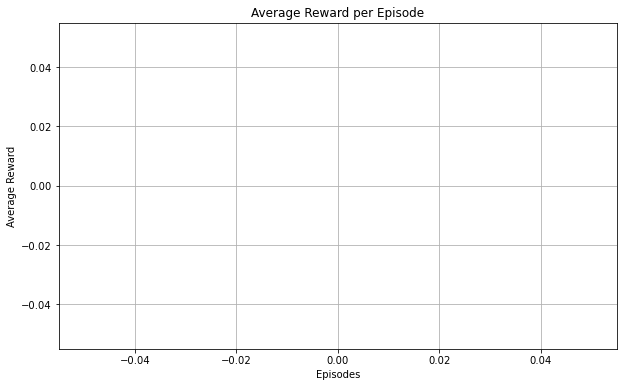

In [142]:
import matplotlib.pyplot as plt

print_freq = 100

average_rewards = [sum(all_episode_rewards[i:i+print_freq]) / print_freq for i in range(0, len(all_episode_rewards), print_freq)]
episodes = [i for i in range(0, len(all_episode_rewards), print_freq)]

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(episodes, average_rewards, marker='o', linestyle='-', color='b')
plt.title("Average Reward per Episode")
plt.xlabel("Episodes")
plt.ylabel("Average Reward")
plt.grid(True)
plt.show()

## Section 12: Plot Average Rewards Over Episodes


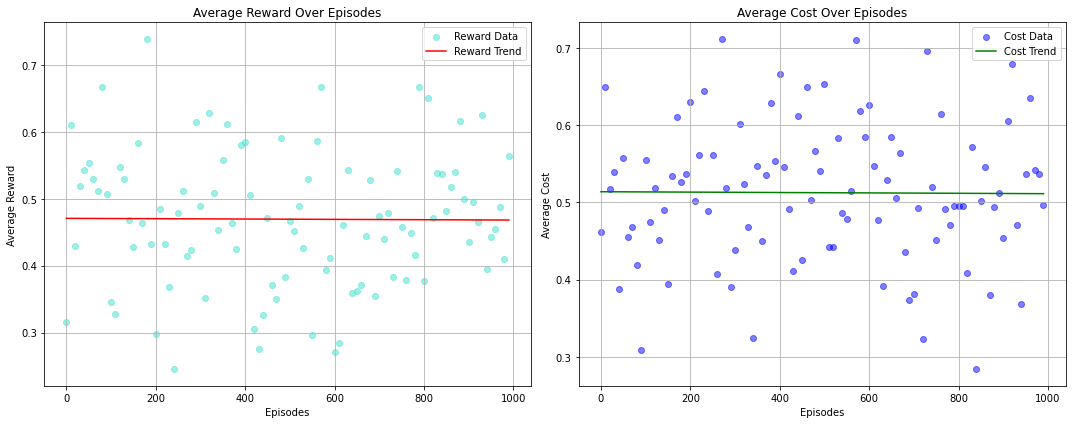

In [143]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Your simulated data or training loop data
all_episode_rewards = [np.random.rand() for _ in range(1000)]  # Replace with your training loop data
all_episode_costs = [np.random.rand() for _ in range(1000)]  # Replace with your training loop data
print_freq = 10

# Your analysis code
if len(all_episode_rewards) >= print_freq:
    average_rewards = [np.mean(all_episode_rewards[i:i+print_freq]) for i in range(0, len(all_episode_rewards), print_freq)]
    average_costs = [np.mean(all_episode_costs[i:i+print_freq]) for i in range(0, len(all_episode_costs), print_freq)]
    episodes = [i*print_freq for i in range(len(average_rewards))]

    # Calculate trend lines for rewards and costs
    slope_reward, intercept_reward, _, _, _ = stats.linregress(episodes, average_rewards)
    slope_cost, intercept_cost, _, _, _ = stats.linregress(episodes, average_costs)
    line_reward = intercept_reward + slope_reward * np.array(episodes)
    line_cost = intercept_cost + slope_cost * np.array(episodes)
    
    # Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))  # Corrected subplot creation

    # Plot rewards on the first subplot
    ax1.scatter(episodes, average_rewards, alpha=0.5, label='Reward Data', color='turquoise')
    ax1.plot(episodes, line_reward, 'r', label='Reward Trend')
    ax1.set_title('Average Reward Over Episodes')
    ax1.set_xlabel('Episodes')
    ax1.set_ylabel('Average Reward')
    ax1.legend()
    ax1.grid(True)

    # Plot costs on the second subplot
    ax2.scatter(episodes, average_costs, alpha=0.5, label='Cost Data', color='blue')
    ax2.plot(episodes, line_cost, 'g', label='Cost Trend')
    ax2.set_title('Average Cost Over Episodes')
    ax2.set_xlabel('Episodes')
    ax2.set_ylabel('Average Cost')
    ax2.legend()
    ax2.grid(True)
    
    # Display the plot
    plt.tight_layout()
    plt.show()
else:
    print("Not enough data to calculate trend lines.")


## Section 13: Save and Load the Trained Model
Saves the trained model's state dictionary to a file and then loads it back into a new instance of the ActorCriticNetwork for evaluation.

In [144]:
torch.save(actor_critic.state_dict(), 'saved_models/actor_critic_state.pth')
actor_critic = ActorCriticNetwork(obs_space_size=153, action_space_size=30)
actor_critic.load_state_dict(torch.load('saved_models/actor_critic_state.pth'))
actor_critic.eval()

ActorCriticNetwork(
  (shared_layers): Sequential(
    (0): Linear(in_features=153, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
  )
  (policy_layers): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=30, bias=True)
    (3): Softmax(dim=-1)
  )
  (value_layers): Linear(in_features=128, out_features=1, bias=True)
)